Installing necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import librosa #for audio file processing and analysis
import librosa.display #for visualizing audio data

In [2]:
#Configuration parameters
s_rate = 16000 # Sample rate in Hz
duration = 10  # seconds
N_MFCC = 30 # number of MFCC coefficients
N_FFT = 2048 # length of the FFT window
N_MELS = 128 # number of Mel bands to generate
Folds = 4

In [3]:
data_path = Path(r'D:\02_Work\04_projects\DC motor sound analysis\Dataset\BLDC_sound_data')
print('Loading the dataset')

Loading the dataset


In [4]:
record = []
tar_leng = int(s_rate*duration)

print("data_path =", data_path)
print("exists:", data_path.exists())
print("is_dir:", data_path.is_dir())
print("Folders:", list(data_path.iterdir()))


for class_dir in sorted(data_path.iterdir()):
  if not class_dir.is_dir():
        continue
  raw_label = class_dir.name
  for audio_file in sorted(class_dir.rglob('*.wav')):
    y,_ = librosa.load(audio_file, sr=s_rate, duration = duration)
    
    # if in case the audio file is shorter than the expected duration, we are doing padding for the remaing part of the audio
    if len(y)<tar_leng:
        y = np.pad(y, (0, tar_leng - len(y)), mode='constant')
    else:
       y = y[:tar_leng]
       y = np.array(y, dtype=np.float32)
    record.append((y, s_rate, raw_label, audio_file.name))
print('The audio file has been loaded')

print(f"\nTotal records loaded : {len(record)}")
print(f"Classes found        : {sorted(set(r[2] for r in record))}")

data_path = D:\02_Work\04_projects\DC motor sound analysis\Dataset\BLDC_sound_data
exists: True
is_dir: True
Folders: [WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Bearing'), WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Healthy'), WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Propeller')]
The audio file has been loaded

Total records loaded : 43
Classes found        : ['Bearing', 'Healthy', 'Propeller']


Exploratory data analysis of the audio files:

In [5]:
labels = [r[2] for r in record] 
unique = set(labels) # removes duplicate labels
unique = sorted(unique) # sort the unique labels
print('The unique labels are: ', unique)

counts = pd.Series(labels).value_counts() # count the number of occurrences of each label
print('The count of each label is: \n', counts)

The unique labels are:  ['Bearing', 'Healthy', 'Propeller']
The count of each label is: 
 Healthy      22
Propeller    14
Bearing       7
Name: count, dtype: int64


Class distribution chart

Text(0.5, 0, 'Labels')

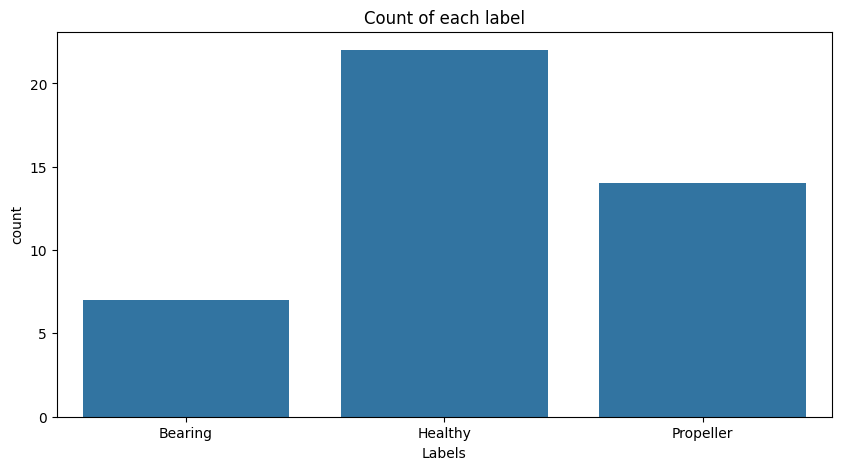

In [6]:
fig,ax = plt.subplots(figsize=(10,5))
sns.countplot(x=labels, ax=ax)
ax.set_title('Count of each label')
ax.set_xlabel('Labels')


waveform grid

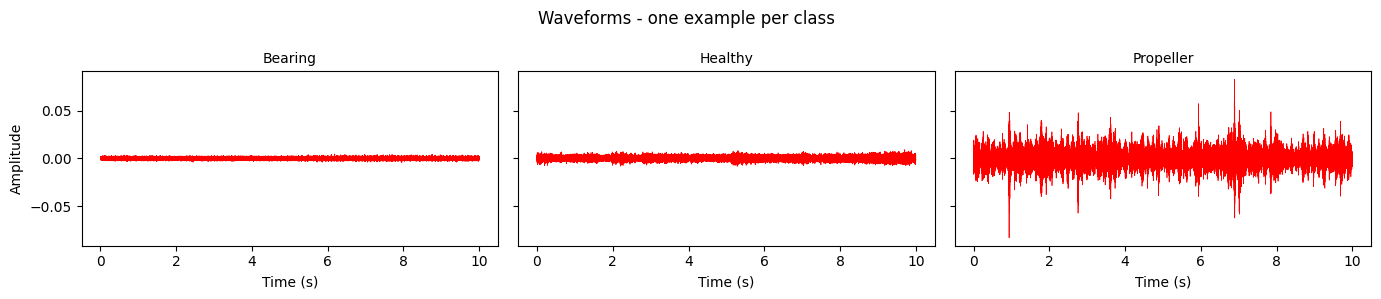

In [22]:
fig, axes = plt.subplots(1, len(unique), figsize=(14, 3), sharey=True) # sharey for sharing the y axis scale across all the subplots
for ax, lbl in zip(axes, unique):    # loop through each unique label and corresponding subplot axis
        audio, sr, label, fname = next(r for r in record if r[2] == lbl) # get the first sample for each label
        y = audio
        sr = s_rate
        t = np.linspace(0, len(y)/sr, len(y))
        ax.plot(t, y, lw=0.5, color="red")
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
fig.suptitle("Waveforms - one example per class")
plt.tight_layout()
plt.show()

Mel Spectrogram Grid: (visual representation of sound that converts frquency to mel scale for human pitch perception). Transforms audio into an image - time on x axis and mel frequency on y axis by fourier transformation. y axis in log scale and decibels in color scale. Then the y scale is mapped onto the mel scale and the corresponding spectrogram is mel spectrogram.
https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53.
For better explaination from scratch view:https://youtu.be/9GHCiiDLHQ4?si=xqr1vy89PSTFdazy.

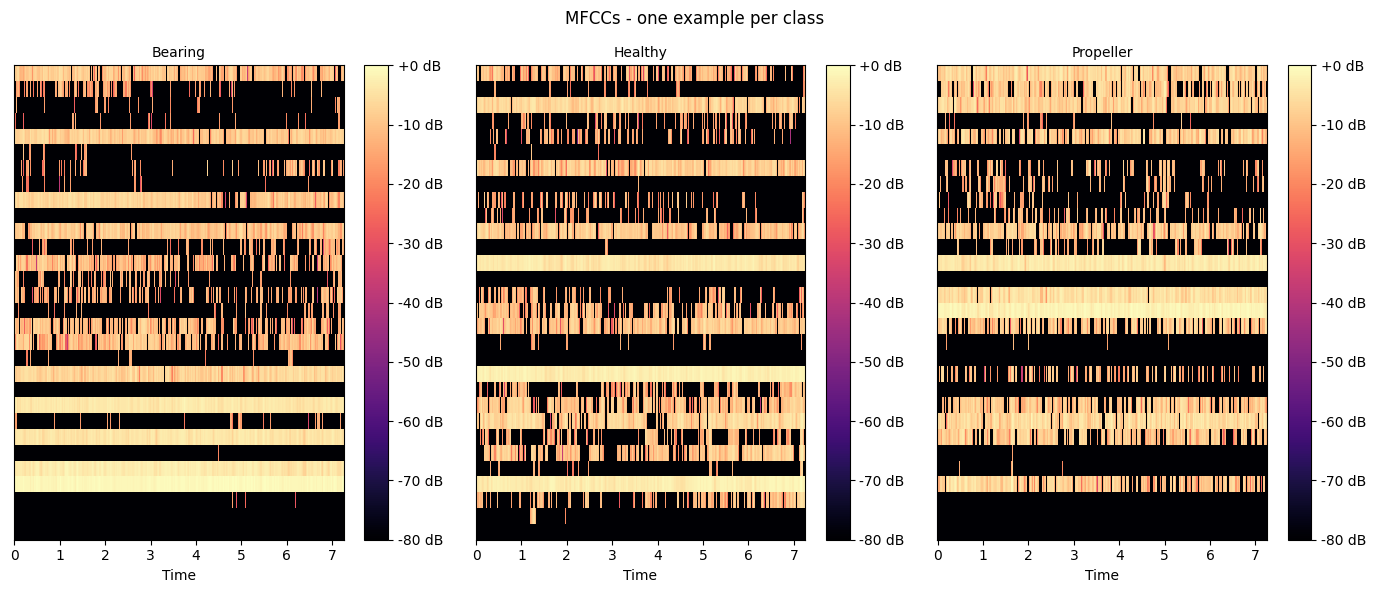

In [8]:
fig, axes = plt.subplots(1, len(unique), figsize=(14, 6))
for ax, lbl in zip(axes, unique):
    audio, sr, label, fname = next(r for r in record if r[2] == lbl) # get the first sample for each label
    y = audio
    mfccs = librosa.feature.mfcc(y=y, sr=s_rate, n_mfcc=N_MFCC)
    mfccs_db = librosa.power_to_db(mfccs, ref=np.max) # convert to decibel scale
    img = librosa.display.specshow(mfccs_db, x_axis='time', ax=ax)
    ax.set_title(lbl, fontsize=10)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
fig.suptitle("MFCCs - one example per class")
plt.tight_layout()
plt.show()

Fast Fourier Transform Spectrum:

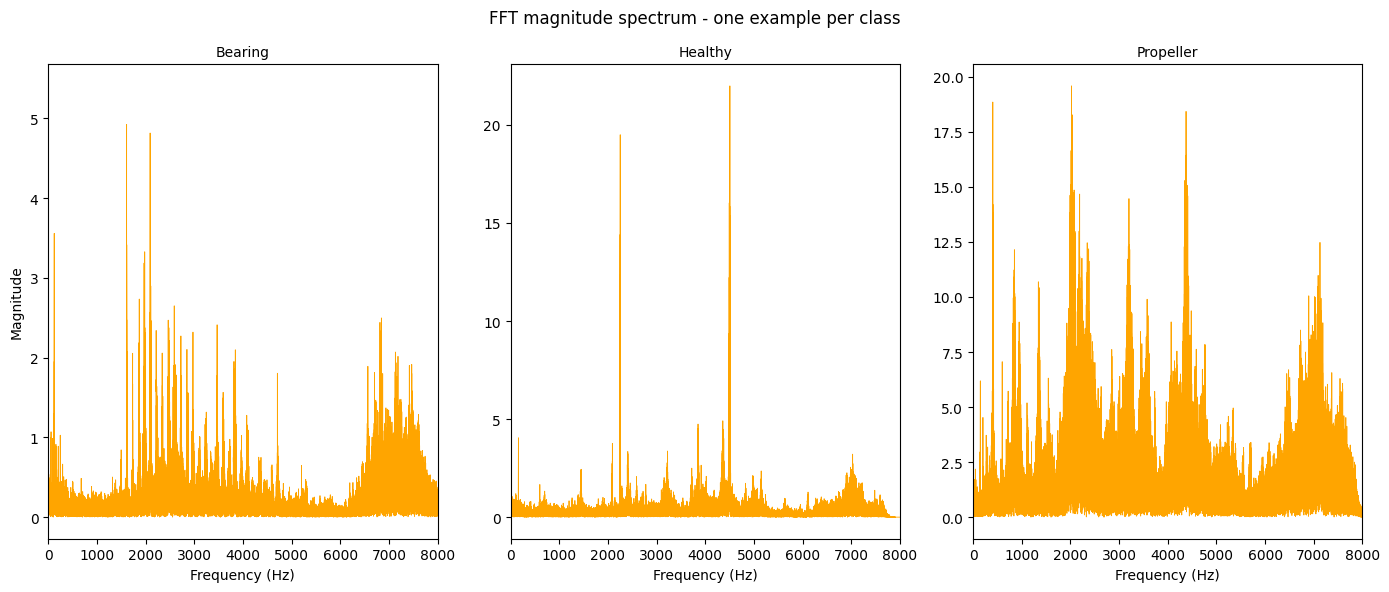

In [21]:
fig, axes = plt.subplots(1, len(unique), figsize=(14, 6))
for ax, lbl in zip(axes, unique):
    audio, sr, label, fname = next(r for r in record if r[2] == lbl)
    y = audio
    fft    = np.abs(np.fft.rfft(y))
    freqs  = np.fft.rfftfreq(len(y), d=1/s_rate)
    ax.plot(freqs, fft, lw=0.6, color="orange")
    ax.set_xlim(0, s_rate // 2)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
fig.suptitle("FFT magnitude spectrum - one example per class")
plt.tight_layout()
plt.show()

Frequency and Time Domain Feature extraction

In [10]:
def extract_features(y, s_rate):
  features = [] # to save all the extracted time and frequency domain features
  # MFCC - Mel Frequency Cepstral Coefficients
  mfcc = librosa.feature.mfcc(y=y, sr=s_rate, n_mfcc = N_MFCC)
  mfcc_mean = np.mean(mfcc, axis =1)
  mfcc_std = np.std(mfcc, axis =1)
  features.extend([float(x) for x in mfcc_std])

  # Spectral centroid
  spec_cent = librosa.feature.spectral_centroid(y=y, sr=s_rate)
  features.extend([float(np.mean(spec_cent)), float(np.std(spec_cent))])

  # Spectral bandwidth
  spec_band = librosa.feature.spectral_bandwidth(y=y, sr=s_rate)
  features.extend([float(np.mean(spec_band)), float(np.std(spec_band))])

  # Spectral rolloff
  spec_roll = librosa.feature.spectral_rolloff(y=y, sr=s_rate)
  features.extend([float(np.mean(spec_roll)), float(np.std(spec_roll))])

  # Chroma STFT
  chroma = librosa.feature.chroma_stft(y=y, sr=s_rate)
  chroma_mean = np.mean(chroma, axis =1)
  features.extend([float(x) for x in chroma_mean])
  chroma_std = np.std(chroma, axis =1)
  features.extend([float(x) for x in chroma_std])

  # Some of the time domain features
  # Zero Crossing Rate
  zero_cross_rate = librosa.feature.zero_crossing_rate(y)
  features.extend([float(np.mean(zero_cross_rate)), float(np.std(zero_cross_rate))])

  # RMS energy
  rms = librosa.feature.rms(y=y)
  features.extend([float(np.mean(rms)), float(np.std(rms))]) 

  features = np.array(features, dtype=np.float32)
  return features

Building the feature matrix

In [11]:
x = []
y_labels = []
file_names = []

for y, sr, label, fname in record:
  sr = s_rate
  feat = extract_features(y, sr)
  x.append(feat)
  y_labels.append(label)
  file_names.append(fname)
print(f" {fname}:{feat.shape[0]} features extracted")
x = np.array(x)
y_labels = np.array(y_labels)
print('Feature extraction is completed')
print(f"Feature matrix shape : {x.shape}")
print(f"Unique labels        : {np.unique(y_labels)}")

  

 2000.wav:64 features extracted
Feature extraction is completed
Feature matrix shape : (43, 64)
Unique labels        : ['Bearing' 'Healthy' 'Propeller']


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score, cross_validate

In [13]:
# Encoding the labels
le = LabelEncoder()
y = le.fit_transform(y_labels)
print('Labels have been encoded')

# Splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Labels have been encoded


In [14]:
# Machine learning model training and Evaluation
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipelines = {
  "SVM (RBF)": Pipeline([("scaler", StandardScaler()),("clf", SVC(kernel="rbf", C=5, gamma="scale",
  class_weight="balanced", random_state=42, probability=True))]),

  "Random Forest": Pipeline([("scaler", StandardScaler()),("clf", RandomForestClassifier(n_estimators=10, 
  max_depth=None, class_weight="balanced",random_state =42))]),

  "Gradient Boosting": Pipeline([("scaler", StandardScaler()),("clf", GradientBoostingClassifier(n_estimators=200,
  learning_rate=0.05, max_depth= 6,random_state=42))]),

  "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=6, metric="euclidean"))]),
}

print(pipelines.keys())

dict_keys(['SVM (RBF)', 'Random Forest', 'Gradient Boosting', 'KNN'])


In [15]:
# Training the ML pipelines and validating the performance using cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipe in pipelines.items():
  cv_result = cross_validate(pipe, x_train, y_train, cv =cv, scoring = ["accuracy", "f1_weighted"])
  results[name] = {
    "val_accuracy": cv_result["test_accuracy"].mean(),
    "val_f1_weighted": cv_result["test_f1_weighted"].mean(),
    "val_std_accuracy": cv_result["test_accuracy"].std(),
  }
  print(f"{name}")
  print(f"Validation Accuracy: {results[name]['val_std_accuracy']:.4f}, F1-Weighted: {results[name]['val_f1_weighted']:.4f}")
  print(f"Validation Accuracy Std: {results[name]['val_std_accuracy']:.4f}")

SVM (RBF)
Validation Accuracy: 0.0667, F1-Weighted: 0.7610
Validation Accuracy Std: 0.0667
Random Forest
Validation Accuracy: 0.1524, F1-Weighted: 0.6922
Validation Accuracy Std: 0.1524
Gradient Boosting
Validation Accuracy: 0.0646, F1-Weighted: 0.7340
Validation Accuracy Std: 0.0646
KNN
Validation Accuracy: 0.0857, F1-Weighted: 0.5978
Validation Accuracy Std: 0.0857


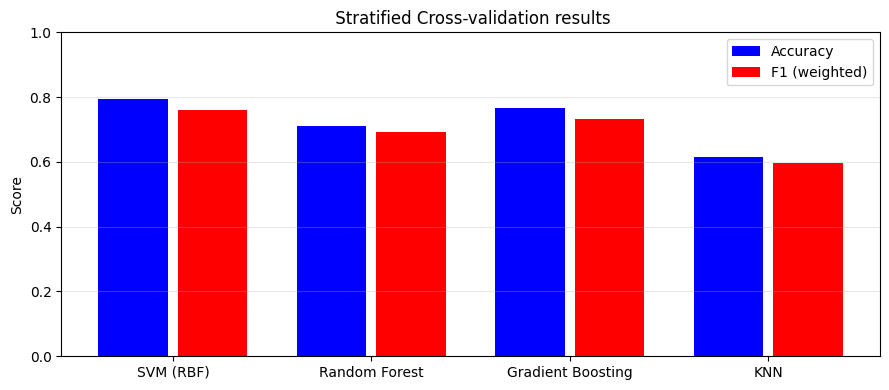

In [19]:
names   = list(results.keys())
accs    = [results[n]["val_accuracy"] for n in names]
stds    = [results[n]["val_std_accuracy"] for n in names]
f1s     = [results[n]["val_f1_weighted"] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(x - 0.2, accs, 0.35, label="Accuracy", color="blue", capsize=5)
ax.bar(x + 0.2, f1s, 0.35, label="F1 (weighted)", color="red")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(" Stratified Cross-validation results")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Hyperparameter optimization using Gridsearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for each model using GridSearchCV
param_grids = {
    "SVM (RBF)": {
        "clf__C":     [0.1, 1, 5, 10, 50],
        "clf__gamma": ["scale", "auto", 0.001, 0.01],
        "clf__kernel":["rbf", "linear"]
    },
    "Random Forest": {
        "clf__n_estimators": [10,20, 40, 50, 100, 200],
        "clf__max_depth":    [None, 5, 10, 20],
        "clf__min_samples_split": [2, 5, 10]
    },
    "Gradient Boosting": {
        "clf__n_estimators":  [10,20, 40, 50, 100],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__max_depth":     [3, 4, 6]
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 9, 11],
        "clf__metric":      ["euclidean", "manhattan", "minkowski"],
        "clf__weights":     ["uniform", "distance"]
    }
}

best_models = {}
grid_search_results = {}

for name, pipe in pipelines.items():
  print(f"Tuning: {name}")
    
  grid_search = GridSearchCV(
    estimator  = pipe,
    param_grid = param_grids[name],
    cv         = cv,
    scoring    = "f1_weighted",      # optimise for F1 given class imbalance
    refit      = True,               # refit best model on full x_train
    n_jobs     = -1,                 # use all CPU cores
    verbose    = 1)

  grid_search.fit(x_train, y_train)

  best_models[name]    = grid_search.best_estimator_
  grid_search_results[name] = {
  "best_params":  grid_search.best_params_,
  "best_f1":      grid_search.best_score_,
  "cv_results":   grid_search.cv_results_}

  print(f"  Best params : {grid_search.best_params_}")
  print(f"  Best F1     : {grid_search.best_score_:.4f}")

print("Summary - best F1 per model")
for name, res in grid_search_results.items():
    print(f"  {name:20s}: {res['best_f1']:.4f}  {res['best_params']}")

best_name = max(grid_search_results, key=lambda n: grid_search_results[n]["best_f1"])
best_pipe = best_models[best_name]
print(f"\nBest overall model: {best_name}")


Tuning: SVM (RBF)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Best params : {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
  Best F1     : 0.7815
Tuning: Random Forest
Fitting 5 folds for each of 72 candidates, totalling 360 fits
  Best params : {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
  Best F1     : 0.8357
Tuning: Gradient Boosting
Fitting 5 folds for each of 45 candidates, totalling 225 fits
  Best params : {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 40}
  Best F1     : 0.7340
Tuning: KNN
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best params : {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
  Best F1     : 0.8037
Summary - best F1 per model
  SVM (RBF)           : 0.7815  {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
  Random Forest       : 0.8357  {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_

Classification Report:              precision    recall  f1-score   support

     Bearing       1.00      1.00      1.00         1
     Healthy       1.00      1.00      1.00         4
   Propeller       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



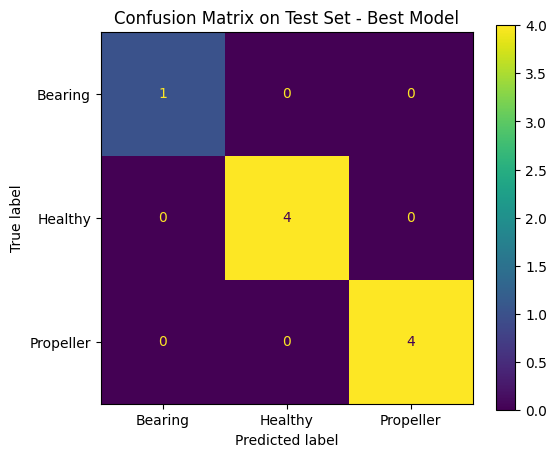

In [20]:
# Predicting the test set with the best model : i.e the random forest classifier with the best hyperparameters
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = best_pipe.predict(x_test)
report = classification_report(y_test, y_pred, target_names=le.classes_)
print("Classification Report:" + report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix on Test Set - Best Model")
plt.show()
